In [85]:
# IMPORTS

import pandas as pd                     # dataframe functionality
import geopandas as gpd                 # geodataframe functionality

from pathlib import Path                # helps with Windows filepaths
from shapely.geometry import Point      # for buffer analysis
import matplotlib.pyplot as plt         # mapping

import contextily as cx                 # basemaps
from datetime import datetime           # for file timestamps

import numpy as np
from shapely.geometry import MultiPoint
from shapely.geometry import box
from matplotlib_scalebar.scalebar import ScaleBar

In [86]:
# --- Paths ---
DATA_ROOT = Path(r"C:\Users\orinj\Documents\Python\Basemap Generator\data")

paths = {
    "borough_boundaries":           DATA_ROOT / "borough_boundaries.gpkg",
    "building_footprints":          DATA_ROOT / "bk_qn_building_footprints.gpkg",
    "subway_lines":                 DATA_ROOT / "subway_lines.gpkg",
    "pavement_edge":                DATA_ROOT / "pavement_edge.gpkg",
    "sidewalks":                    DATA_ROOT / "sidewalks.gpkg",
    "pluto":                        DATA_ROOT / "pluto.gpkg",
    "streets":                      DATA_ROOT / "streets.gpkg",
    "parks":                        DATA_ROOT / "parks.gpkg",
}

In [87]:
map_type = "land_use"  # Options: "base", "zoning", "land_use"

map_configs = {
    "base": {
        "title": "Basemap",
        "layers": {
            "borough_boundaries": {"color": "white", "edgecolor": "none", "zorder": 10},
            "parks":              {"color": "green", "edgecolor": "none", "alpha": 0.5, "zorder": 20},
            "building_footprints":{"color": "gray",  "edgecolor": "black","alpha": 0.5, "zorder": 21},
            "pavement_edge":      {"color": "black", "linewidth": 0.25,   "zorder": 31},
            "sidewalks":          {"color": "lightgray", "linewidth": 0.25, "zorder": 32},
            "subway_lines":       {"linewidth": 2.5, "zorder": 40},  # color handled separately
        }
    },
    # "zoning": {
    #     "title": "Zoning Map",
    #     "layers": {
    #         "borough_boundaries": {"color": "white", "edgecolor": "none", "zorder": 10},
    #         "pluto":              {"column": "zonedist", "zorder": 20},  # choropleth by zone
    #         "pavement_edge":      {"color": "black", "linewidth": 0.25, "zorder": 31},
    #     }
    # },
    "land_use": {
        "title": "Land Use Map",
        "layers": {
            "borough_boundaries": {"color": "white", "edgecolor": "none", "zorder": 10},
            "pluto":              {"edgecolor": "gray", "alpha": 0.75, "zorder": 20},  # color handled separately
            "pavement_edge":      {"color": "black", "linewidth": 0.25, "zorder": 31},
            "sidewalks":          {"color": "lightgray", "linewidth": 0.25, "zorder": 32},
            "subway_lines":       {"linewidth": 2.5, "zorder": 40},  # color handled separately
        }
    },
}


In [98]:
''' 
Establish map centerpoint and buffer range
'''

location_input = "40.64317496732342, -74.02370556494591"
mile = 5280

longitude = float(location_input.split(',')[1].strip())
latitude = float(location_input.split(',')[0].strip())

# Buffer distance in feet
buffer_ft = mile * .25

# Padding to show detail outside of circular buffer
padding = 1.5

# Best projected CRS for NYC is EPSG:2263 (NAD83 / New York Long Island (ftUS))
basemap_crs = 2263


# Create layer dictionary to hold loaded data
layers = {}

# Save location as a layer
layers['location'] = gpd.GeoDataFrame(geometry=[Point(longitude, latitude)], crs="EPSG:4326").to_crs(basemap_crs)

# Create buffer as a layer
layers["location"]["buffer"] = layers["location"].geometry.buffer(buffer_ft)
layers["location"]["padded_buffer"] = layers["location"].geometry.buffer(buffer_ft * padding)

In [99]:
''' 
Establish map extent
'''

# Extract buffer geometry for extent
buffer = layers["location"]["buffer"].iloc[0]

# Get extent from buffer bounds
xmin, ymin, xmax, ymax = buffer.bounds



In [100]:
''' 
Read files into geopandas (this step can take a minute)
'''

# Reads data into geopandas using buffer, accounting for variable CRS and layer specifications
def read_with_buffer(path, buffer):
    
    # Read just the metadata to get the file's CRS (no features loaded)
    file_crs = gpd.read_file(path, rows=0).crs
    
    # Reproject buffer from basemap CRS to match the file's CRS
    buffer_reprojected = gpd.GeoSeries([buffer], crs=basemap_crs).to_crs(file_crs).iloc[0]
    
    # Read the file filtered by the reprojected buffer
    layer = gpd.read_file(path, bbox=buffer_reprojected)
    
    return layer

layers["borough_boundaries"] = read_with_buffer(paths['borough_boundaries'], buffer)
layers["building_footprints"] = read_with_buffer(paths['building_footprints'], buffer)
layers["subway_lines"] = read_with_buffer(paths['subway_lines'], buffer)
layers["pavement_edge"] = read_with_buffer(paths['pavement_edge'], buffer)
layers["sidewalks"] = read_with_buffer(paths['sidewalks'], buffer)
layers["pluto"] = read_with_buffer(paths['pluto'], buffer)
# layers["streets"] = read_with_buffer(paths['streets'], buffer)
layers["parks"] = read_with_buffer(paths['parks'], buffer)


In [101]:
''' 
Set all layers to the same CRS
'''

# Set each layer CRS to EPSG:2263
for layer_name in list(layers.keys()):
    layers[layer_name] = layers[layer_name].to_crs(basemap_crs)


In [102]:
''' 
Filter layers by location buffer
'''

for layer_name in list(layers.keys()):
    if layer_name == "location":
        continue
    layers[layer_name] = layers[layer_name][layers[layer_name].intersects(layers["location"]["padded_buffer"].iloc[0])]

In [ ]:
'''
Clip layers to map extent (keeps output file size low)

- removes features portions that extend beyond the map extent
'''

# Create a square clipping box from the map extent
clip_box = gpd.GeoDataFrame(geometry=[box(xmin, ymin, xmax, ymax)], crs=basemap_crs)

for layer_name in list(layers.keys()):
    if layer_name == "location":
        continue
    layers[layer_name] = gpd.clip(layers[layer_name], clip_box)

In [104]:
''' 
Set subway line colors
'''

# create color map to set color by value
subways_color_map = {
    "G": "lightgreen",
    "L": "lightgray",
    "S": "darkgray",
    "7": "purple",

    "J": "brown",
    "Z": "brown",
    "J-Z": "brown",

    "A": "blue",
    "C": "blue",
    "E": "blue",
    "A-C": "blue",
    "A-C-E": "blue",

    "B": "orange",
    "D": "orange",
    "F": "orange",
    "M": "orange",
    "B-D": "orange",
    "F-M": "orange",

    "N": "gold",
    "Q": "gold",
    "R": "gold",
    "W": "gold",
    "N-Q": "gold",
    "N-Q-R": "gold",
    "R-W": "gold",
    "N-W": "gold",
    "N-R-W": "gold",
    "N-R": "gold",
    "N-Q-R-W": "gold",

    "1": "red",
    "2": "red",
    "3": "red",
    "1-2": "red",
    "2-3": "red",
    "1-2-3": "red",

    "4": "green",
    "5": "green",
    "6": "green",
    "4-5": "green",
    "4-5-6": "green",

    "SIR": "lightblue",
}

# Map the column to the color map
layers['subway_lines']["subway_color"] = layers['subway_lines']["name"].map(subways_color_map).fillna("gray")

In [105]:
'''
Set land use colors and descriptions

All land use colors
['07' '06' '10' '01' '02' '11' '04' None '05' '08' '09' '03']

Source for colors: https://www.nyc.gov/assets/planning/download/pdf/applicants/applicant-portal/area_map_standard.pdf
Reason for tuple of RGB values: https://matplotlib.org/stable/users/explain/colors/colors.html
'''
# create color and description maps
land_use_color_map = {
    "01": np.array([255, 255, 179]) / 255,            # One & Two Family Buildings
    "02": np.array([255, 235, 138]) / 255,            # Multi-Family Walk-Up Buildings
    "03": np.array([255, 196, 0]) / 255,              # Multi-Family Elevator Buildings 
    "04": np.array([255, 153, 102]) / 255,            # Mixed Residential & Commercial Buildings 
    "05": np.array([232, 51, 51]) / 255,              # Commercial & Office Buildings
    "06": np.array([171, 89, 201]) / 255,             # Industrial & Manufacturing
    "07": np.array([255, 204, 255]) / 255,            # Transportation & Utility
    "08": np.array([46, 109, 255]) / 255,             # Public Facilities & Institutions
    "09": np.array([153, 255, 102]) / 255,            # Open Space & Outdoor Recreation
    "10": np.array([170, 170, 170]) / 255,            # Parking Facilities
    "11": np.array([46, 46, 46]) / 255,               # Vacant Land
    None: np.array([235, 235, 235]) / 255,            # None
}
land_use_description_map = {
    "01": "One & Two Family Buildings",
    "02": "Multi-Family Walk-Up Buildings",
    "03": "Multi-Family Elevator Buildings",
    "04": "Mixed Residential & Commercial Buildings",
    "05": "Commercial & Office Buildings",
    "06": "Industrial & Manufacturing",
    "07": "Transportation & Utility",
    "08": "Public Facilities & Institutions",
    "09": "Open Space & Outdoor Recreation",
    "10": "Parking Facilities",
    "11": "Vacant Land",
    None: "none",                                        # None
}

# Map the column to the color map
layers['pluto']["land_use_color"] = layers['pluto']["LandUse"].map(land_use_color_map).fillna("none")
layers['pluto']["land_use_description"] = layers['pluto']["LandUse"].map(land_use_description_map).fillna("none")

In [106]:
'''
Add scale bar
'''
def add_scale_bar():
    scale = ScaleBar(
        dx=1/5280,
        units='mi',
        dimension='imperial-length',
        fixed_units='mi',   # specify units
        fixed_value=0.25,    # specify number of units to show
        location="lower left",
        color="black",
        box_color="none",
        box_alpha=0,  # box transparency
        font_properties={'family': 'Arial'}     # Set font
    )
    return scale

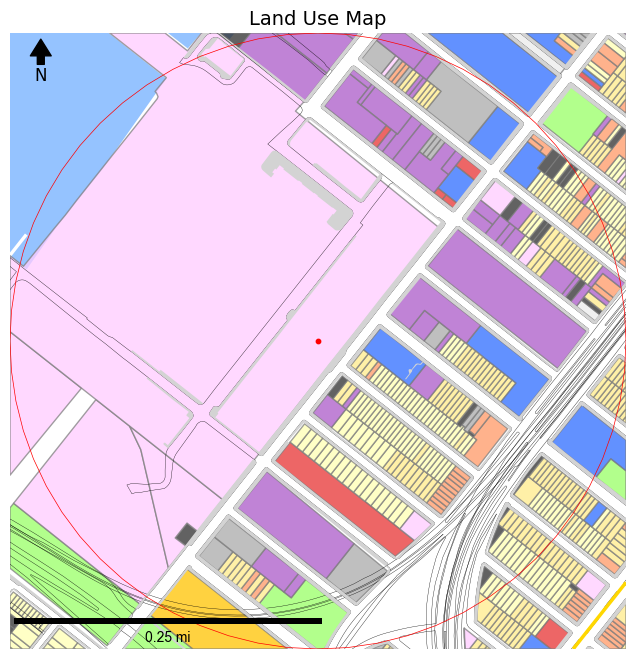

In [107]:
''' 
Plot layers and set up output
'''

# Plot
fig, ax = plt.subplots(figsize=(8, 8))

# Background rectangle (water)
ax.add_patch(
    plt.Rectangle(
        (xmin, ymin),
        xmax - xmin,
        ymax - ymin,
        facecolor="#95c3ff",
        edgecolor="none",
        zorder=0
    )
)

# Plot location and buffer area
layers["location"].plot(ax=ax, color="red", markersize=10, alpha=1, zorder=50)
layers["location"]["buffer"].plot(ax=ax, color="none", edgecolor="red", linewidth=.5, alpha=1, zorder=50)


# Plot layers based on map type configuration
config = map_configs[map_type]
ax.set_title(config["title"], fontsize=14)

for layer_name, style in config["layers"].items():
    if layer_name not in layers:
        continue
    layer = layers[layer_name]
    style = style.copy()

    # Subway lines and land use need special color handling
    if layer_name == "subway_lines":
        layer.plot(ax=ax, color=layer["subway_color"], **style)
    elif layer_name == "pluto":
        layer.plot(ax=ax, color=layer["land_use_color"], **style)
    else:
        layer.plot(ax=ax, **style)


# Set extent
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

# Remove axes for a cleaner look - .axis("off") does not work with facecolor
ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
for spine in ax.spines.values():
    spine.set_visible(False)

# --- NORTH ARROW ---
x, y, arrow_length = 0.05, .99, 0.06  # Position and size in axis fraction
ax.annotate('N',
    xy=(x, y),
    xytext=(x, y - arrow_length),
    arrowprops=dict(facecolor='black', width=5, headwidth=15),
    ha='center', va='center',
    fontsize=12,
    xycoords=ax.transAxes)

# --- SCALE BAR ---
scalebar = add_scale_bar()
ax.add_artist(scalebar)
scalebar.set_zorder(100)

plt.show()